<a href="https://colab.research.google.com/github/Sherry66410/ML-PROJECT/blob/main/Customer_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [2]:
df=pd.read_csv("/content/customer_churn.csv")

In [3]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0.0,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0.0,No,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0.0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0.0,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0.0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0.0,Yes,Yes,24.0,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0.0,Yes,Yes,72.0,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0.0,Yes,Yes,11.0,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1.0,Yes,No,4.0,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [4]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,float64
Partner,object
Dependents,object
tenure,float64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [5]:

df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,7
Partner,0
Dependents,0
tenure,13
PhoneService,13
MultipleLines,13
InternetService,37
OnlineSecurity,15


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7036 non-null   float64
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7030 non-null   float64
 6   PhoneService      7030 non-null   object 
 7   MultipleLines     7030 non-null   object 
 8   InternetService   7006 non-null   object 
 9   OnlineSecurity    7028 non-null   object 
 10  OnlineBackup      7028 non-null   object 
 11  DeviceProtection  7028 non-null   object 
 12  TechSupport       7028 non-null   object 
 13  StreamingTV       7021 non-null   object 
 14  StreamingMovies   7029 non-null   object 
 15  Contract          7018 non-null   object 
 16  PaperlessBilling  7029 non-null   object 


In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7036.000000,7030.000000,7027.000000
mean,0.162024,32.367568,64.757855
std,0.368499,24.560644,30.091845
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
# Drop non-informative ID column
df = df.drop(columns=['customerID'])



In [12]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Converted 'TotalCharges' to numeric type, coercing errors to NaN.")

Converted 'TotalCharges' to numeric type, coercing errors to NaN.


In [15]:
# Identify numerical columns that might have missing values
numerical_cols_with_nan = df[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']].columns[df[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']].isnull().any()].tolist()

# Impute missing numerical values with the median
for col in numerical_cols_with_nan:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"Imputed missing values in '{col}' with median: {median_val}")

print("Numerical missing values imputed successfully.")

Numerical missing values imputed successfully.


In [14]:
# Verify that numerical columns no longer have missing values
print("Missing values after numerical imputation:")
print(df[numerical_cols_with_nan].isnull().sum())

Missing values after numerical imputation:
SeniorCitizen     0
tenure            0
MonthlyCharges    0
TotalCharges      0
dtype: int64


In [16]:
# Identify categorical columns that might have missing values
categorical_cols_with_nan = df.select_dtypes(include='object').columns[df.select_dtypes(include='object').isnull().any()].tolist()

# Impute missing categorical values with the mode
for col in categorical_cols_with_nan:
    mode_val = df[col].mode()[0] # .mode() returns a Series, so take the first element
    df[col] = df[col].fillna(mode_val)
    print(f"Imputed missing values in '{col}' with mode: {mode_val}")

print("Categorical missing values imputed successfully.")

Imputed missing values in 'PhoneService' with mode: Yes
Imputed missing values in 'MultipleLines' with mode: No
Imputed missing values in 'InternetService' with mode: Fiber optic
Imputed missing values in 'OnlineSecurity' with mode: No
Imputed missing values in 'OnlineBackup' with mode: No
Imputed missing values in 'DeviceProtection' with mode: No
Imputed missing values in 'TechSupport' with mode: No
Imputed missing values in 'StreamingTV' with mode: No
Imputed missing values in 'StreamingMovies' with mode: No
Imputed missing values in 'Contract' with mode: Month-to-month
Imputed missing values in 'PaperlessBilling' with mode: Yes
Imputed missing values in 'PaymentMethod' with mode: Electronic check
Categorical missing values imputed successfully.


In [18]:
# Verify that all columns no longer have missing values
print("Missing values after all imputations:")
print(df.isnull().sum())

Missing values after all imputations:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [19]:
print('Churn distribution:')
print(df['Churn'].value_counts())
churn_rate = df['Churn'].value_counts(normalize=True)['Yes'] * 100
print(f'\nChurn Rate: {churn_rate:.1f}%')

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.5%


In [20]:
# Encode target variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [21]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0.0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0.0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0.0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0.0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0.0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0.0,Yes,Yes,24.0,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0
7039,Female,0.0,Yes,Yes,72.0,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0
7040,Female,0.0,Yes,Yes,11.0,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0
7041,Male,1.0,Yes,No,4.0,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1


In [ ]:
#EDA

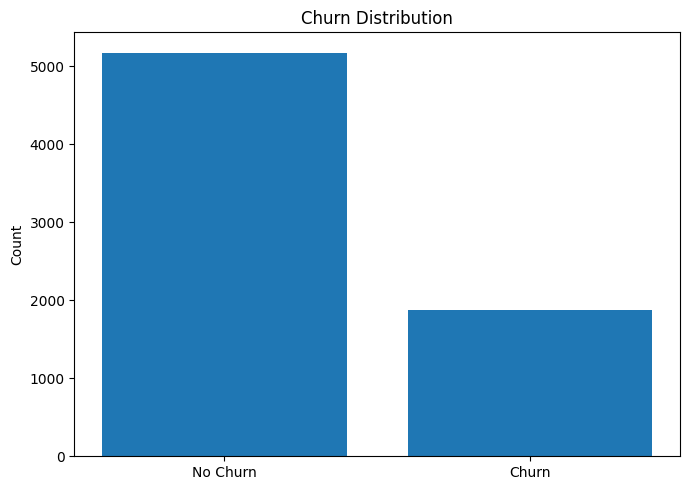

In [39]:
fig_churn_dist, ax_churn_dist = plt.subplots(figsize=(7, 5))
churn_counts = df['Churn'].value_counts()
ax_churn_dist.bar(['No Churn', 'Churn'], churn_counts.values)
ax_churn_dist.set_title('Churn Distribution')
ax_churn_dist.set_ylabel('Count')
ax_churn_dist.tick_params(axis='x', labelsize=10)
ax_churn_dist.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.show()

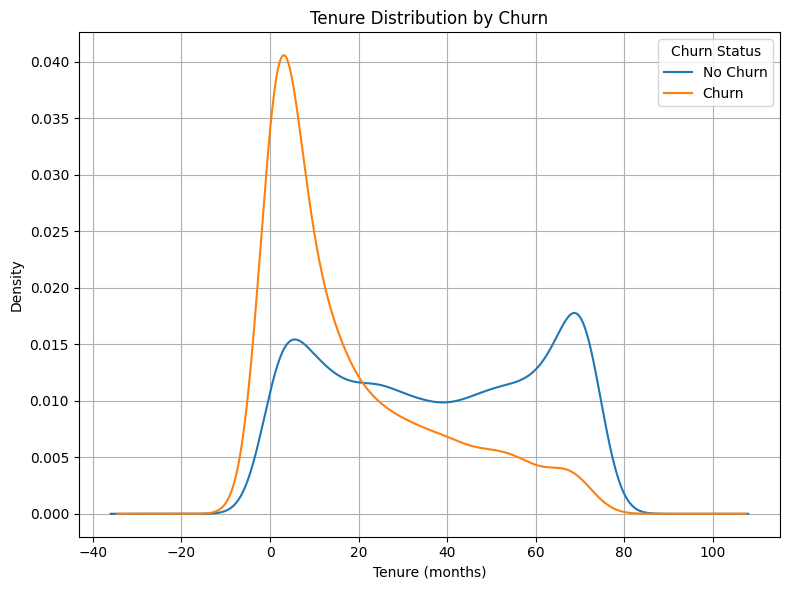

In [40]:
#Tenure kde
fig_tenure_kde, ax_tenure_kde = plt.subplots(figsize=(8, 6))
for label, grp in df.groupby('Churn')['tenure']:
    grp.plot(kind='kde', ax=ax_tenure_kde, label='Churn' if label==1 else 'No Churn')
ax_tenure_kde.set_title('Tenure Distribution by Churn')
ax_tenure_kde.set_xlabel('Tenure (months)')
ax_tenure_kde.set_ylabel('Density')
ax_tenure_kde.legend(title='Churn Status')
ax_tenure_kde.tick_params(axis='both')
ax_tenure_kde.grid(True)
plt.tight_layout()
plt.show()

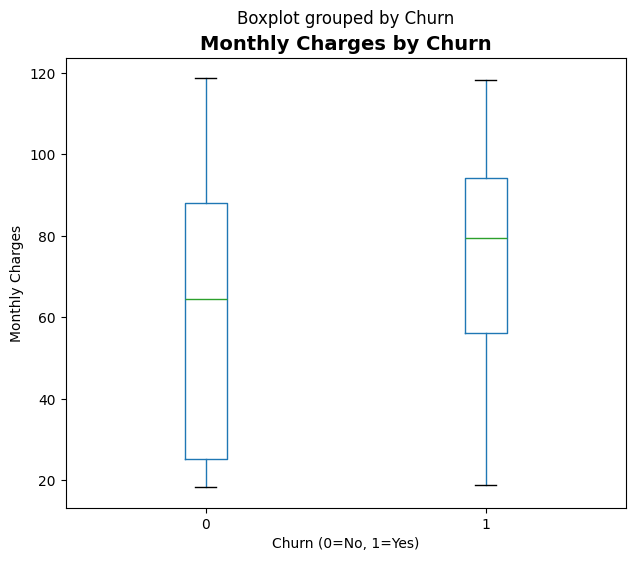

In [43]:
fig_monthly_boxplot, ax_monthly_boxplot = plt.subplots(figsize=(7, 6))
df.boxplot(column='MonthlyCharges', by='Churn', ax=ax_monthly_boxplot,grid=False)
ax_monthly_boxplot.set_title('Monthly Charges by Churn', fontsize=14, fontweight='bold')
ax_monthly_boxplot.set_xlabel('Churn (0=No, 1=Yes)')
ax_monthly_boxplot.set_ylabel('Monthly Charges')
ax_monthly_boxplot.tick_params(axis='both')
plt.show()

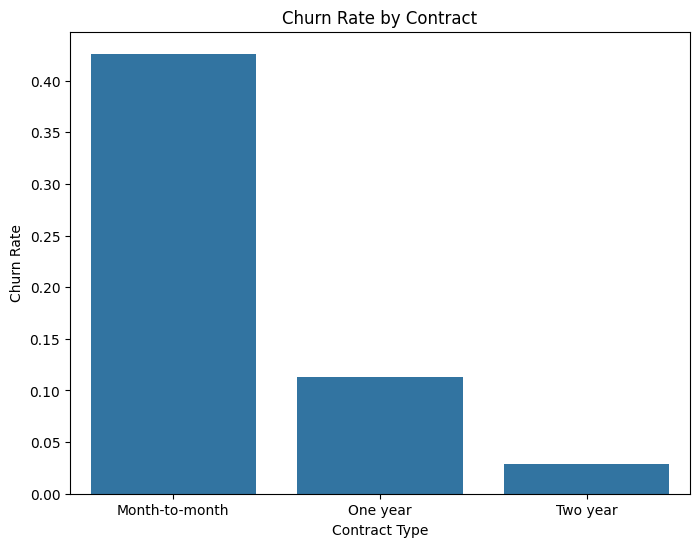

In [44]:
import seaborn as sns

fig_contract_churn, ax_contract_churn = plt.subplots(figsize=(8, 6))
contract_churn = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False)
sns.barplot(x=contract_churn.index, y=contract_churn.values, ax=ax_contract_churn)
ax_contract_churn.set_title('Churn Rate by Contract')
ax_contract_churn.set_ylabel('Churn Rate')
ax_contract_churn.set_xlabel('Contract Type')
ax_contract_churn.tick_params(axis='x')
ax_contract_churn.tick_params(axis='y')
plt.show()

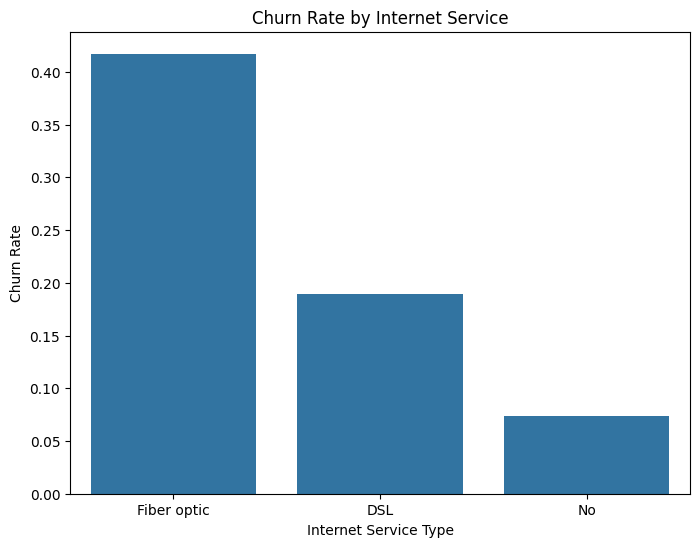

In [45]:
fig_internet_churn, ax_internet_churn = plt.subplots(figsize=(8, 6))
internet_churn = df.groupby('InternetService')['Churn'].mean().sort_values(ascending=False)
sns.barplot(x=internet_churn.index, y=internet_churn.values, ax=ax_internet_churn,)
ax_internet_churn.set_title('Churn Rate by Internet Service')
ax_internet_churn.set_ylabel('Churn Rate')
ax_internet_churn.set_xlabel('Internet Service Type')
ax_internet_churn.tick_params(axis='x')
ax_internet_churn.tick_params(axis='y')
plt.show()

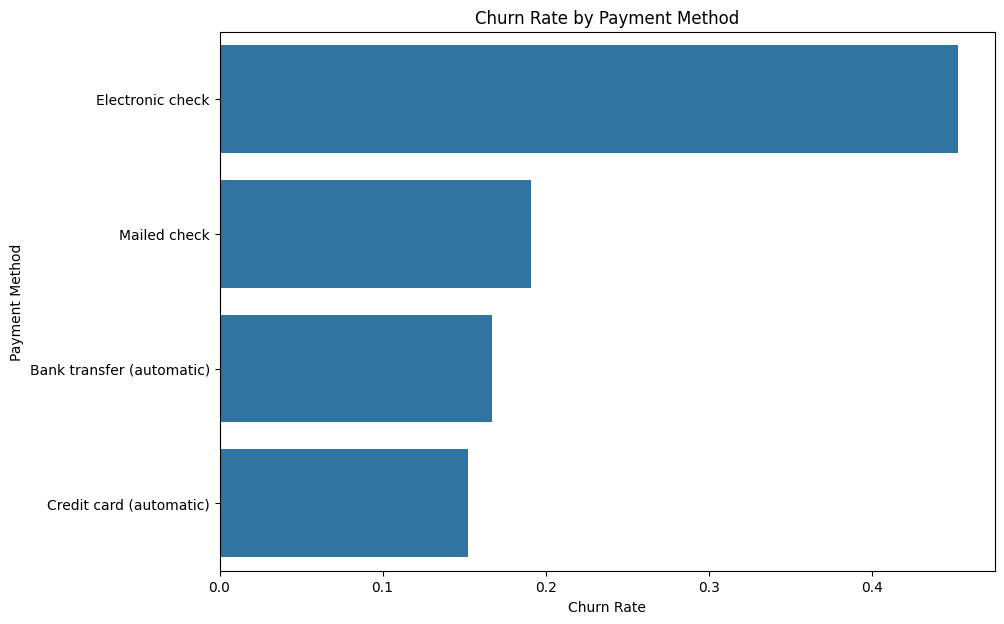

In [47]:
fig_payment_churn, ax_payment_churn = plt.subplots(figsize=(10, 7))
payment_churn = df.groupby('PaymentMethod')['Churn'].mean().sort_values(ascending=False)
sns.barplot(x=payment_churn.values, y=payment_churn.index, ax=ax_payment_churn)
ax_payment_churn.set_title('Churn Rate by Payment Method')
ax_payment_churn.set_xlabel('Churn Rate')
ax_payment_churn.set_ylabel('Payment Method')
ax_payment_churn.tick_params(axis='both')
plt.show()

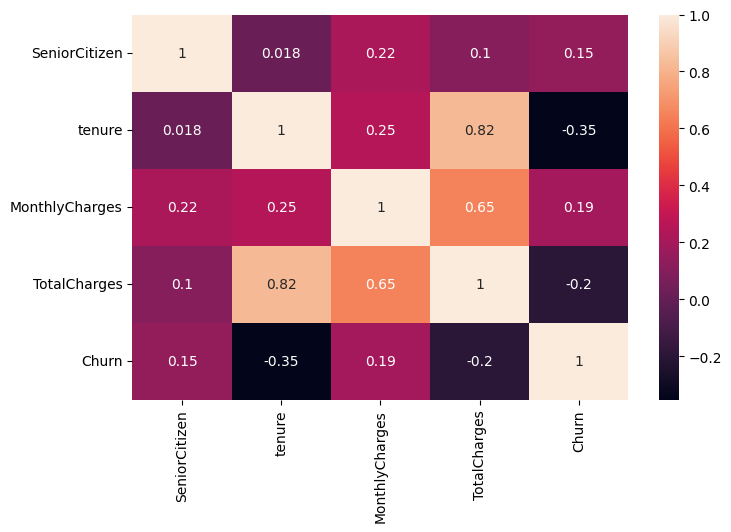

In [49]:
# Correlation heatmap
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(8, 5))
corr = df[num_cols + ['Churn']].corr()
sns.heatmap(corr, annot=True)
plt.show()

In [50]:
#Feauture engineering and encoding


In [53]:
from sklearn.preprocessing import LabelEncoder
cat_cols = df.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

X = df.drop('Churn', axis=1).astype(float)
y = df['Churn']

In [55]:
print(X.shape)
print(y.shape)

(7043, 19)
(7043,)


In [57]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

print(f'Train: {X_train.shape}  Test: {X_test.shape}')

Train: (5634, 19)  Test: (1409, 19)


In [65]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_tr_sc,y_train)

LogisticRegression()

In [66]:
# Make predictions on the scaled test set
y_pred = model.predict(X_te_sc)
y_pred_proba = model.predict_proba(X_te_sc)[:, 1]

In [70]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("Accuracy: ",accuracy)
print("Precision: ",precision)
print("Recall:",recall)
print("F1-Score:", f1)
print("ROC AUC Score: ",roc_auc)

Accuracy:  0.8147622427253371
Precision:  0.675
Recall: 0.579088471849866
F1-Score: 0.6233766233766234
ROC AUC Score:  0.858924560332067


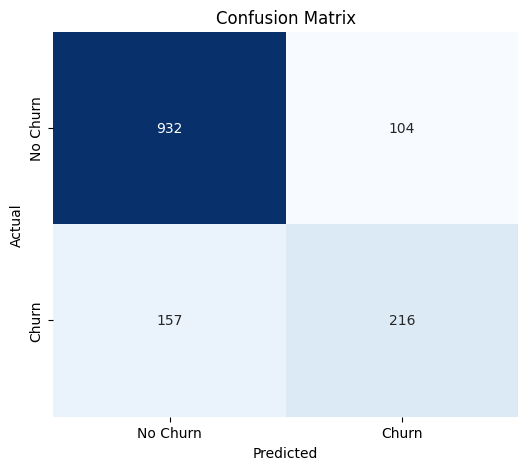

In [68]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

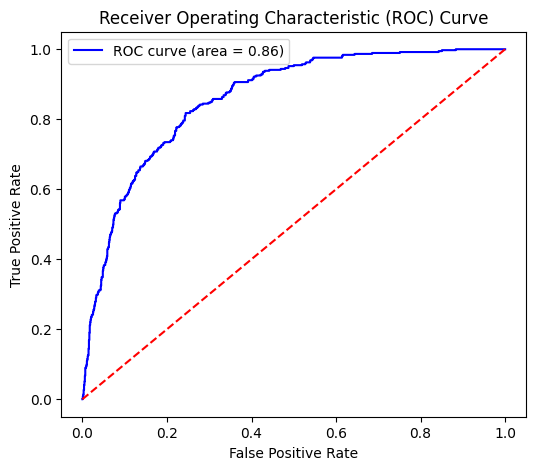

In [69]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

In [ ]:
#Random Forest

In [72]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_tr_sc, y_train)


RandomForestClassifier(random_state=42)

In [84]:
y_pred_rf = rf_model.predict(X_te_sc)
y_pred_proba_rf = rf_model.predict_proba(X_te_sc)[:, 1]

In [85]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1-Score:", f1_rf)
print("ROC AUC Score:", roc_auc_rf)


Accuracy: 0.7955997161107168
Precision: 0.6579925650557621
Recall: 0.4745308310991957
F1-Score: 0.5514018691588785
ROC AUC Score: 0.8340234144523688


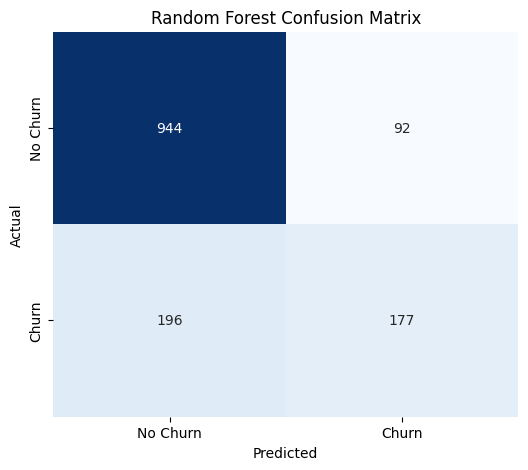

In [75]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

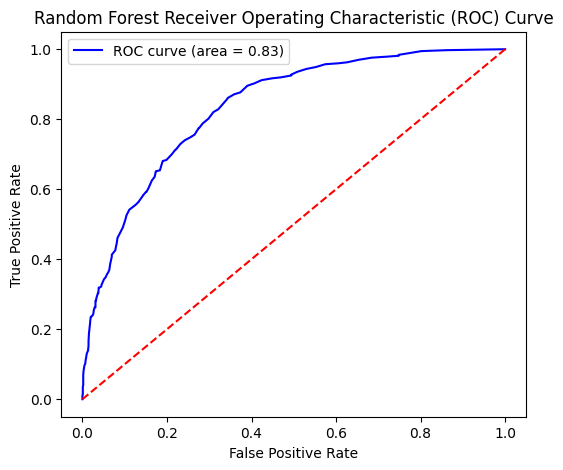

In [76]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)
plt.figure(figsize=(6, 5))
plt.plot(fpr_rf, tpr_rf, color='blue', label=f'ROC curve (area = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

In [ ]:
#XGBoost

In [81]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_tr_sc, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:33:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [82]:

y_pred_xgb = xgb_model.predict(X_te_sc)
y_pred_proba_xgb = xgb_model.predict_proba(X_te_sc)[:, 1]

In [86]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

print("Accuracy:", accuracy_xgb)
print("Precision:", precision_xgb)
print("Recall:", recall_xgb)
print("F1-Score:", f1_xgb)
print("ROC AUC Score:", roc_auc_xgb)

Accuracy: 0.7920511000709723
Precision: 0.6273885350318471
Recall: 0.5281501340482574
F1-Score: 0.5735080058224163
ROC AUC Score: 0.835414359207925


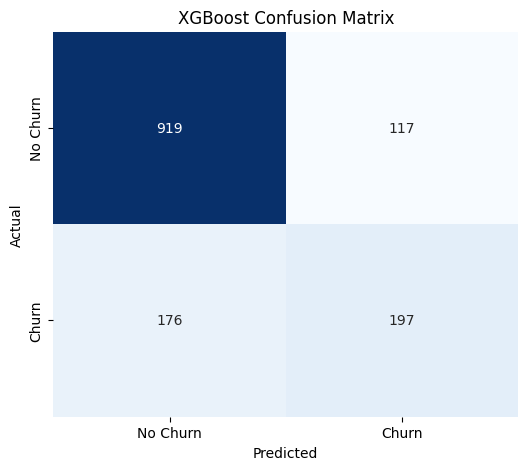

In [87]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Confusion Matrix')
plt.show()

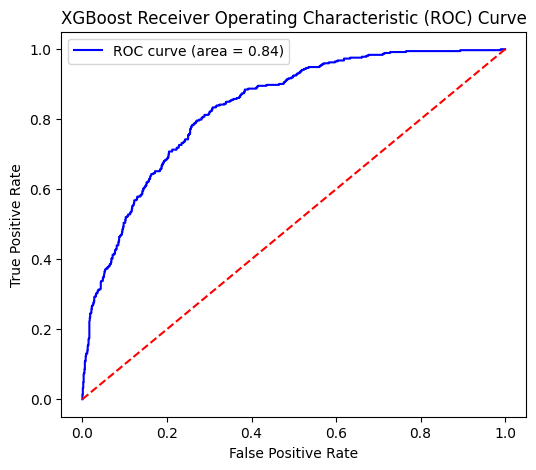

In [88]:
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_pred_proba_xgb)
plt.figure(figsize=(6, 5))
plt.plot(fpr_xgb, tpr_xgb, color='blue', label=f'ROC curve (area = {roc_auc_xgb:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

In [89]:
model_names = ['Logistic Regression', 'Random Forest', 'XGBoost']
metrics = {
    'Accuracy': [accuracy, accuracy_rf, accuracy_xgb],
    'Precision': [precision, precision_rf, precision_xgb],
    'Recall': [recall, recall_rf, recall_xgb],
    'F1-Score': [f1, f1_rf, f1_xgb],
    'ROC AUC Score': [roc_auc, roc_auc_rf, roc_auc_xgb]
}

comparison_df = pd.DataFrame(metrics, index=model_names)
display(comparison_df.round(4))


,Accuracy,Precision,Recall,F1-Score,ROC AUC Score
Logistic Regression,0.8148,0.6750,0.5791,0.6234,0.8589
Random Forest,0.7956,0.6580,0.4745,0.5514,0.8340
XGBoost,0.7921,0.6274,0.5282,0.5735,0.8354
